In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\techr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load Datasets

In [3]:
df1 = pd.read_csv("dataset/Audible_Catlog.csv")
df2 = pd.read_csv("dataset/Audible_Catlog_Advanced_Features.csv")

In [4]:
print(df1.head())
print(df2.head())

                                           Book Name          Author  Rating  \
0  Think Like a Monk: The Secret of How to Harnes...      Jay Shetty     4.9   
1  Ikigai: The Japanese Secret to a Long and Happ...   Héctor García     4.6   
2  The Subtle Art of Not Giving a F*ck: A Counter...     Mark Manson     4.4   
3  Atomic Habits: An Easy and Proven Way to Build...     James Clear     4.6   
4  Life's Amazing Secrets: How to Find Balance an...  Gaur Gopal Das     4.6   

   Number of Reviews    Price  
0              313.0  10080.0  
1             3658.0    615.0  
2            20174.0  10378.0  
3             4614.0    888.0  
4             4302.0   1005.0  
                                           Book Name          Author  Rating  \
0  Think Like a Monk: The Secret of How to Harnes...      Jay Shetty     4.9   
1  Ikigai: The Japanese Secret to a Long and Happ...   Héctor García     4.6   
2  The Subtle Art of Not Giving a F*ck: A Counter...     Mark Manson     4.4   
3  Atom

In [5]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6368 entries, 0 to 6367
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          6368 non-null   object 
 1   Author             6368 non-null   object 
 2   Rating             6368 non-null   float64
 3   Number of Reviews  5737 non-null   float64
 4   Price              6365 non-null   float64
dtypes: float64(3), object(2)
memory usage: 248.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          4464 non-null   object 
 1   Author             4464 non-null   object 
 2   Rating             4464 non-null   float64
 3   Number of Reviews  4043 non-null   float64
 4   Price              4464 non-null   int64  
 5   Description        4458 non-null   object 
 6   Listening

Merge Datasets

In [6]:
df = pd.merge(df1, df2, on=["Book Name","Author","Rating","Number of Reviews","Price"], how="inner")

print(df.shape)
df.head()

(1750, 8)


,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Extraordinary Leadership,Robin Sharma,4.1,179.0,0.0,\nBy completing your purchase you agree to Aud...,1 hour and 6 minutes,",#1 Free in Audible Audiobooks & Originals (Se..."
1,Dream With Your Eyes Open: An Entrepreneurial ...,Ronnie Screwvala,3.6,43.0,0.0,UTV founder and pioneer of the media industry ...,7 hours and 19 minutes,",#2 Free in Audible Audiobooks & Originals (Se..."
2,The Sandman,Neil Gaiman,5.0,1.0,1171.0,Please note: This content is not for kids. It ...,10 hours and 54 minutes,",#16 in Audible Audiobooks & Originals (See To..."
3,Sherlock Holmes: The Definitive Collection,Arthur Conan Doyle,5.0,6.0,3037.0,Now updated to include Chapter Name Informatio...,71 hours and 57 minutes,",#15 in Audible Audiobooks & Originals (See To..."
4,The Warren Buffett Way: 3rd Edition,Robert Hagstrom,4.2,72.0,1005.0,Warren Buffett remains one of the most sought-...,10 hours and 31 minutes,",#17 in Audible Audiobooks & Originals (See To..."


Data Cleaning

In [7]:
df.drop_duplicates(inplace=True)

Handle Missing Values

In [8]:
df.isnull().sum()

Book Name              0
Author                 0
Rating                 0
Number of Reviews    342
Price                  0
Description            1
Listening Time         0
Ranks and Genre        0
dtype: int64

In [9]:
df['Number of Reviews'] = df['Number of Reviews'].fillna(df['Number of Reviews'].median())

In [10]:
df['Description'] = df['Description'].fillna("No description available")

In [11]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [12]:
df.dropna(subset=['Rating'], inplace=True)

In [13]:
df.isnull().sum()

Book Name            0
Author               0
Rating               0
Number of Reviews    0
Price                0
Description          0
Listening Time       0
Ranks and Genre      0
dtype: int64

In [14]:
df['Book Name'] = df['Book Name'].str.replace('\n', ' ')
df['Book Name'] = df['Book Name'].str.strip()

Exploratory Data Analysis (EDA)

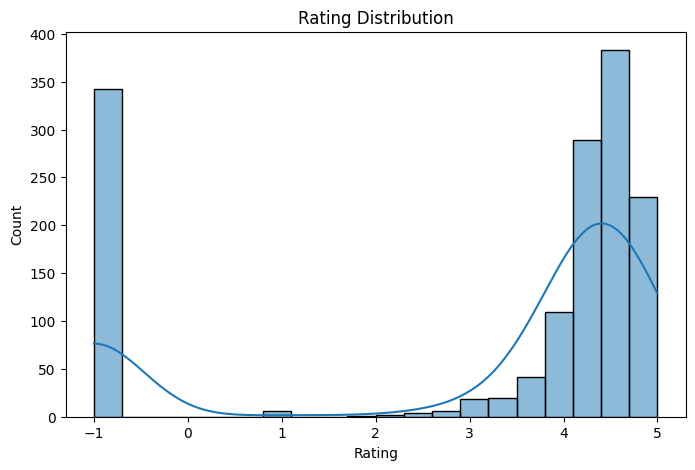

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

Top Genres

In [16]:
df.columns

Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='object')

Create a new Genre column

In [17]:
df['Genre'] = df['Ranks and Genre'].str.replace(r'#\d+\s*in\s*', '', regex=True)

In [18]:
df[['Ranks and Genre','Genre']].head()

,Ranks and Genre,Genre
0,",#1 Free in Audible Audiobooks & Originals (Se...",",#1 Free in Audible Audiobooks & Originals (Se..."
1,",#2 Free in Audible Audiobooks & Originals (Se...",",#2 Free in Audible Audiobooks & Originals (Se..."
2,",#16 in Audible Audiobooks & Originals (See To...",",Audible Audiobooks & Originals (See Top 100 i..."
3,",#15 in Audible Audiobooks & Originals (See To...",",Audible Audiobooks & Originals (See Top 100 i..."
4,",#17 in Audible Audiobooks & Originals (See To...",",Audible Audiobooks & Originals (See Top 100 i..."


In [19]:
top_genres = df['Genre'].value_counts().head(10)

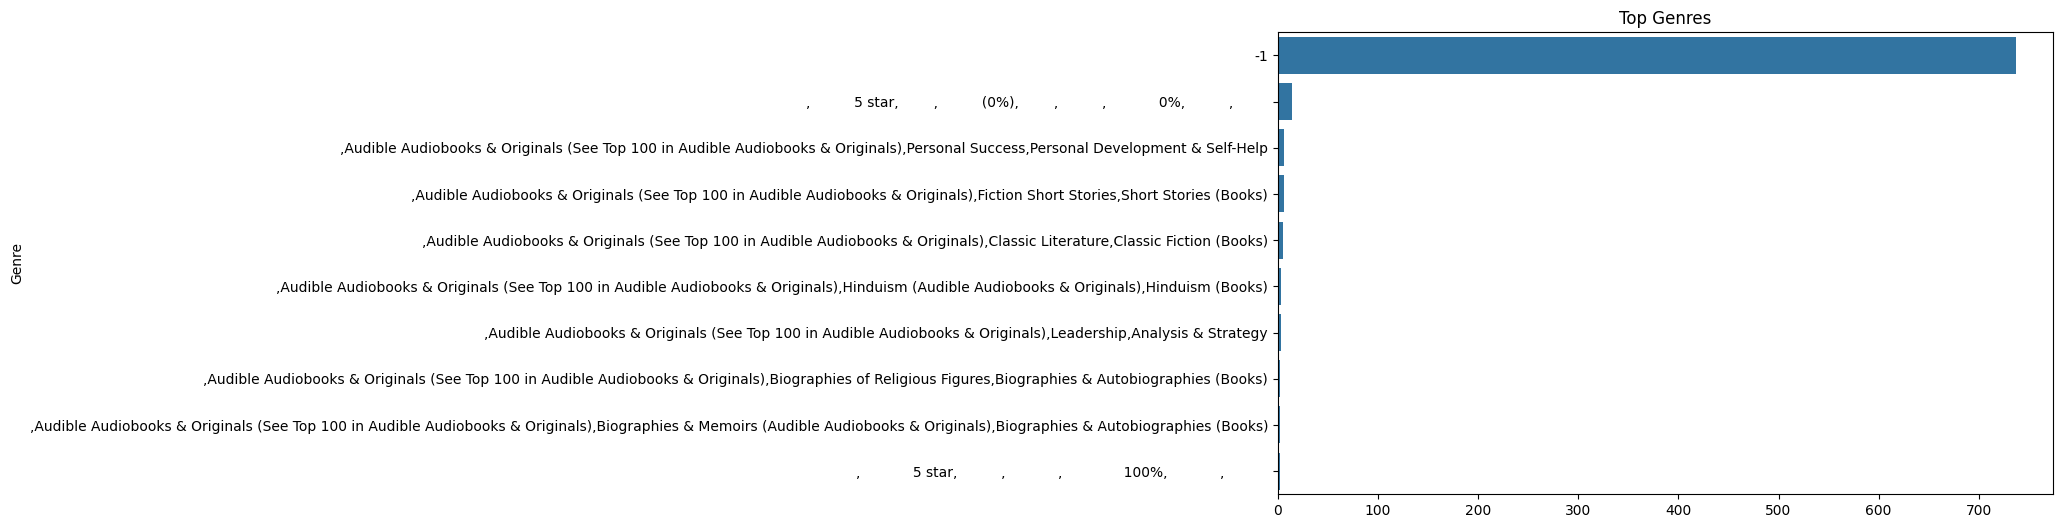

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres")
plt.show()

Rating vs Reviews

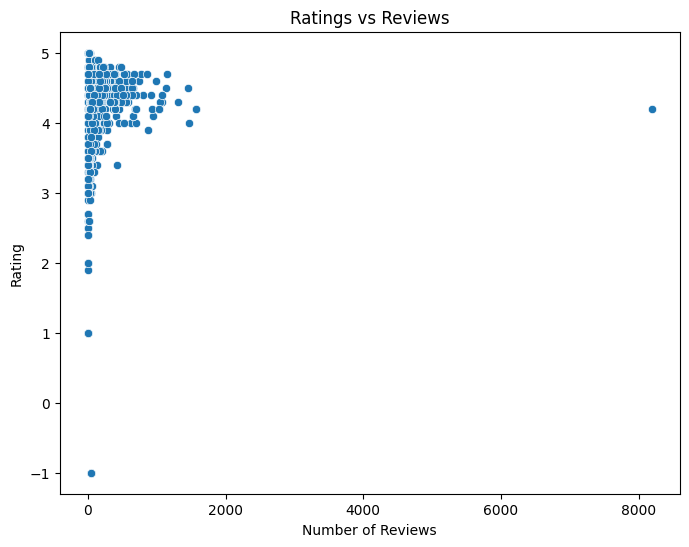

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Number of Reviews'], y=df['Rating'])
plt.title("Ratings vs Reviews")
plt.show()

Correlation Heatmap

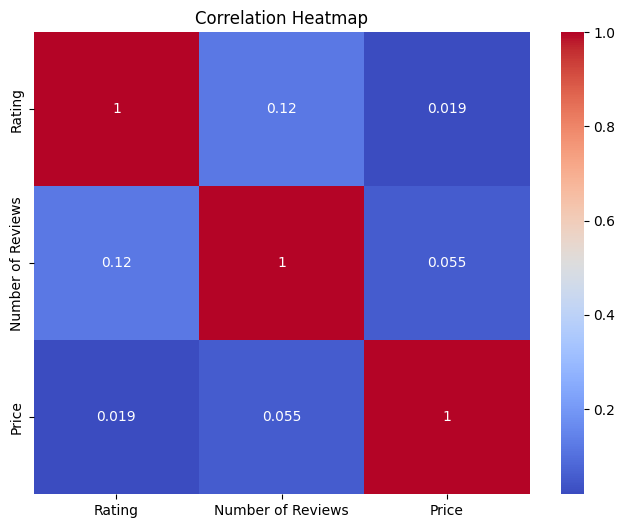

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

NLP Feature Extraction

We use TF-IDF on book descriptions

In [23]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['Description'])

Clustering Books

In [24]:
kmeans = KMeans(n_clusters=10, random_state=42)

df['Cluster'] = kmeans.fit_predict(tfidf_matrix)

Check cluster distribution

In [25]:
df['Cluster'].value_counts()

Cluster
2    358
0    323
1    205
5    135
4    122
7    115
6     87
9     61
3     38
8      8
Name: count, dtype: int64

Content Based Recommendation

Using Cosine Similarity

In [26]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [27]:
def recommend_books(book_name, num_recommendations=5):

    idx = df[df['Book Name'] == book_name].index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    similarity_scores = similarity_scores[1:num_recommendations+1]

    book_indices = [i[0] for i in similarity_scores]

    return df['Book Name'].iloc[book_indices]

Clustering Based Recommendation

In [28]:
def cluster_recommendation(book_name):

    cluster = df[df['Book Name']==book_name]['Cluster'].values[0]

    books = df[df['Cluster']==cluster]

    return books[['Book Name','Author','Rating']].head(5)

Model Evaluation

Precision@K Function

In [29]:
def precision_at_k(recommended, relevant, k=5):
    recommended_k = recommended[:k]
    precision = len(set(recommended_k) & set(relevant)) / k
    return precision

Recall@K Function

In [30]:
def recall_at_k(recommended, relevant, k=5):
    recommended_k = recommended[:k]
    recall = len(set(recommended_k) & set(relevant)) / len(relevant)
    return recall

Create Recommended Books List (from your dataset)

In [31]:
recommended_books = df['Book Name'].head(5).tolist()
recommended_books

['Extraordinary Leadership',
 'Dream With Your Eyes Open: An Entrepreneurial Journey',
 'The Sandman',
 'Sherlock Holmes: The Definitive Collection',
 'The Warren Buffett Way: 3rd Edition']

Create Relevant Books List

In [32]:
relevant_books = df[df['Rating'] > 4]['Book Name'].head(5).tolist()
relevant_books

['Extraordinary Leadership',
 'The Sandman',
 'Sherlock Holmes: The Definitive Collection',
 'The Warren Buffett Way: 3rd Edition',
 "Let's Talk Money: You've Worked Hard for It, Now Make It Work for You"]

Calculate Precision and Recall

In [33]:
precision = precision_at_k(recommended_books, relevant_books, k=5)
recall = recall_at_k(recommended_books, relevant_books, k=5)

print("Precision@5:", precision)
print("Recall@5:", recall)

Precision@5: 0.8
Recall@5: 0.8


Prepare Ratings for RMSE

In [34]:
actual_ratings = df['Rating'].values
predicted_ratings = np.full_like(actual_ratings, df['Rating'].mean())

Calculate RMSE

In [35]:
rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))

print("RMSE:", rmse)

RMSE: 2.2981313506762304


NLP Feature Extraction

Prepare Text Data

We combine Description + Genre + Author to create better text feature

In [36]:
df['text_features'] = df['Description'] + " " + df['Genre'] + " " + df['Author']

Apply TF-IDF

In [37]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['text_features'])

print(tfidf_matrix.shape)

(1452, 9686)


KMeans Clustering

In [38]:
kmeans = KMeans(n_clusters=10, random_state=42)

df['Cluster'] = kmeans.fit_predict(tfidf_matrix)

Check Cluster Distribution

In [39]:
df['Cluster'].value_counts()

Cluster
3    435
9    354
8    283
2    205
4     90
6     38
5     25
0     16
7      4
1      2
Name: count, dtype: int64

Content Based Recommendation

Cosine Similarity

In [40]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

Recommendation Function

In [41]:
def recommend_books(book_name, num_recommendations=5):
    
    idx = df[df['Book Name'] == book_name].index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    similarity_scores = similarity_scores[1:num_recommendations+1]

    book_indices = [i[0] for i in similarity_scores]

    return df[['Book Name','Author','Rating']].iloc[book_indices]

Test Recommendation

In [42]:
recommend_books(df['Book Name'].iloc[10])

,Book Name,Author,Rating
1281,कार सेक्स - एक कामुक लघुकथा,साराह स्‍कोव,-1.0
1202,Flip It: How to Get the Best Out of Everything,Michael Heppell,4.2
1409,The Success Equation: Untangling Skill and Luc...,Michael J. Mauboussin,4.2
1498,Hershey: Milton S. Hershey's Extraordinary Lif...,Michael D'Antonio,4.7
479,"The Search: Finding Your Inner Power, Your Pot...",OSHO,4.6


Save Model Files

In [43]:
os.makedirs("model", exist_ok=True)

In [44]:
pickle.dump(cosine_sim, open('model/similarity.pkl','wb'))
pickle.dump(df, open('model/books.pkl','wb'))